# Internet Log2 data
### Import data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc
from sklearn.svm import SVC

- Read in the log2 files

In [3]:
df = pd.read_csv('../data/log2.csv',header=0)
df.head()


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


In [4]:
df.shape

(65532, 12)

- The data has 11 input features and 1 target label "Action"
- There are total 65532 rows of data

## EDA
### Missing data
- No missing data found
- No imputation needed

In [5]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing'])
missing['Percentage'] = (missing['Missing'] / len(df)) * 100
missing = missing.sort_values(by='Percentage', ascending=True)
missing

,Missing,Percentage
Source Port,0,0.0
Destination Port,0,0.0
NAT Source Port,0,0.0
NAT Destination Port,0,0.0
Action,0,0.0
Bytes,0,0.0
Bytes Sent,0,0.0
Bytes Received,0,0.0
Packets,0,0.0
Elapsed Time (sec),0,0.0


### Distribution of Label Action

In [6]:
df.Action.value_counts()

Action
allow         37640
deny          14987
drop          12851
reset-both       54
Name: count, dtype: int64

<Axes: xlabel='Action', ylabel='Probability'>

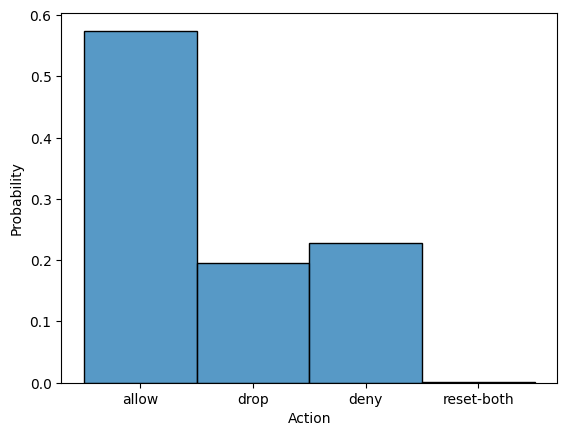

In [7]:
sns.histplot(df.Action,stat='probability')

- There are 4 unevenly distributed group of Action namely Allow, Drop, Deny and Reset. While Allow represent nearly 60% of all label type, the Reset action constitue very small amount.

### Categorical feature variable analysis
- There are four categorical features in the input dataset, represented by the port number: 'Source Port', 'Destination Port', 'NAT Source Port', 'NAT Destination Port'
- Note: ports in internet are not continuous features, instead, they are just arbitrary numbers to represent the connections
- In this feature analysis, we will have to apply One Hot Encoding for all the ports

In [8]:
df_cat = df[['Source Port', 'Destination Port', 'NAT Source Port', 'NAT Destination Port']]

In [9]:
# Calculate unique value statistics for each port feature
port_stats = []
for col in df_cat.columns:
    unique_count = df[col].nunique()
    total_records = len(df)
    percentage_unique = (unique_count / total_records) * 100
    
    port_stats.append({
        'Feature': col,
        'Unique_Values': unique_count,
        'Total_Records': total_records,
        'Percentage_Unique': round(percentage_unique, 2)
    })

# Create and display the results
port_df = pd.DataFrame(port_stats)
print("Port Feature Unique Value Analysis:")
print("=" * 50)
print(port_df.to_string(index=False))

Port Feature Unique Value Analysis:
             Feature  Unique_Values  Total_Records  Percentage_Unique
         Source Port          22724          65532              34.68
    Destination Port           3273          65532               4.99
     NAT Source Port          29152          65532              44.49
NAT Destination Port           2533          65532               3.87


- Distribution of top 10 Ports from these input features:

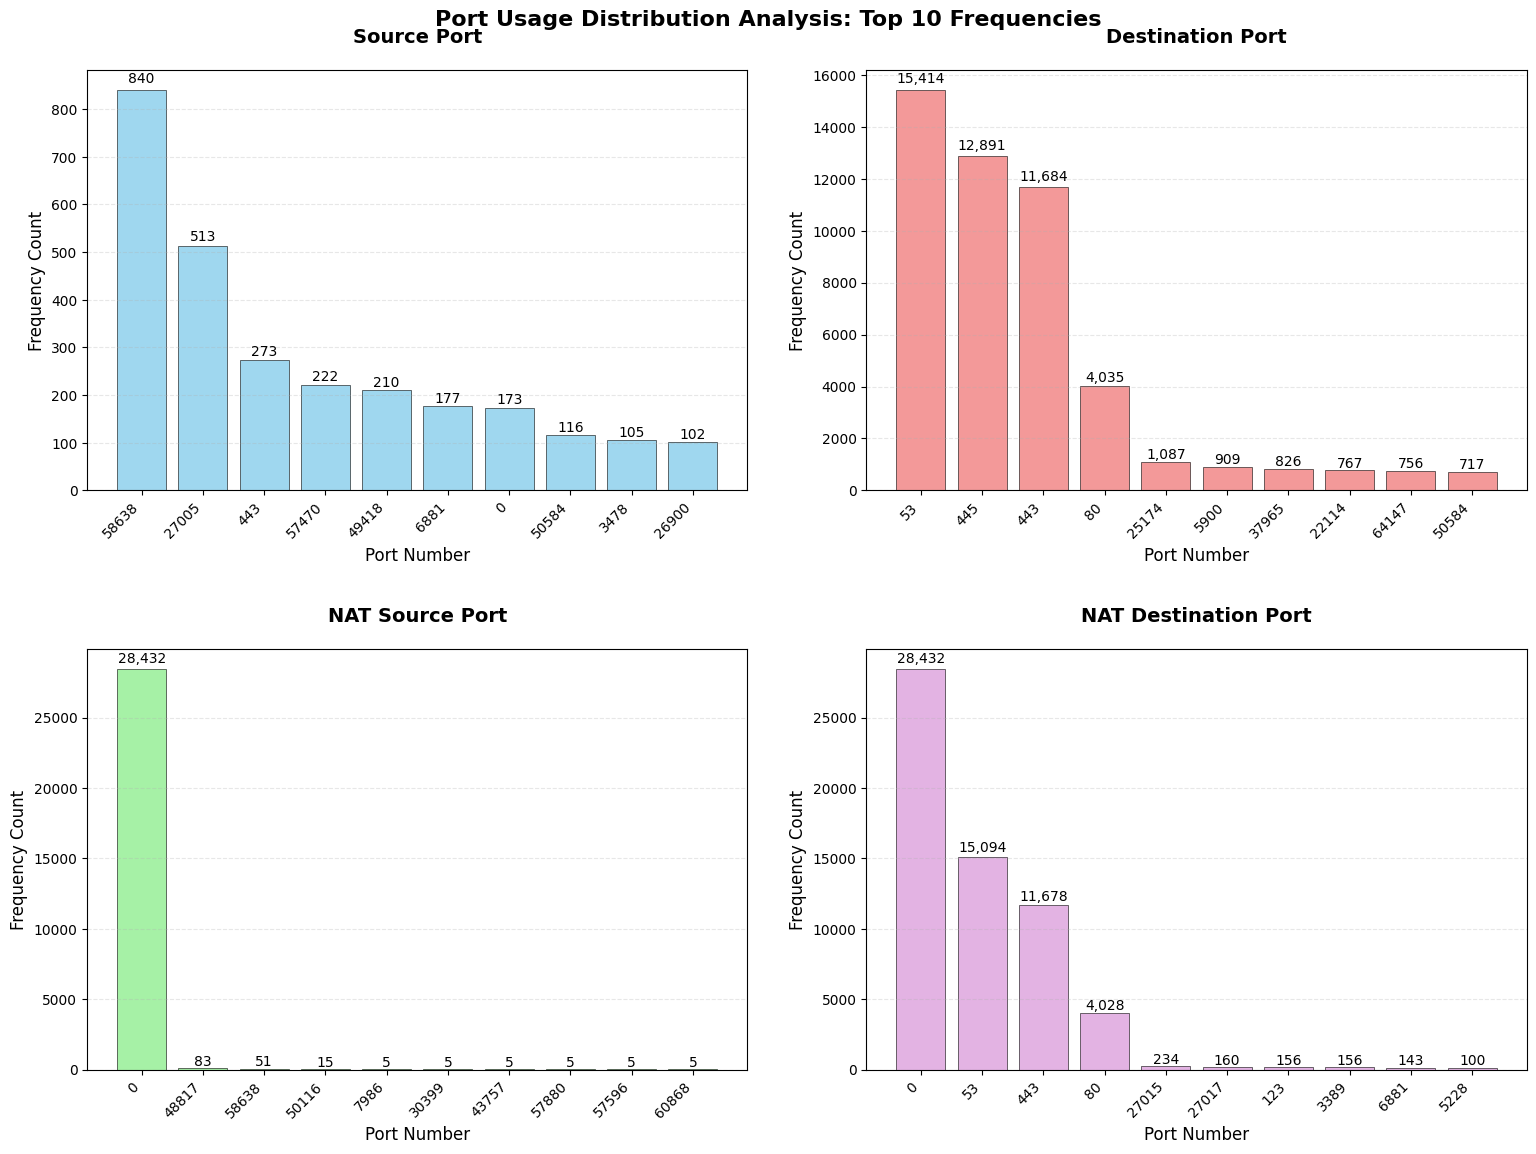

In [10]:
### Top 10 Port Distribution Analysis - 2x2 Subplots

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()  # Flatten for easier indexing

# Get port columns
port_columns = [col for col in df.columns if 'Port' in col]

# Color palette for consistency
colors = ['skyblue', 'lightcoral', 'lightgreen', 'plum']

for i, port_col in enumerate(port_columns):
    # Get top 10 most frequent ports
    top_10_ports = df[port_col].value_counts().head(10)
    # Create histogram for top 10 ports
    bars = axes[i].bar(range(len(top_10_ports)), top_10_ports.values, 
                       color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize the subplot
    axes[i].set_title(f'{port_col}', 
                      fontsize=14, fontweight='bold', pad=20)
    axes[i].set_xlabel('Port Number', fontsize=12)
    axes[i].set_ylabel('Frequency Count', fontsize=12)
    
    # Set x-axis labels to actual port numbers
    axes[i].set_xticks(range(len(top_10_ports)))
    axes[i].set_xticklabels(top_10_ports.index, rotation=45, ha='right')
    
    # Add value labels on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                     f'{int(height):,}', ha='center', va='bottom', fontsize=10)
    
    # Add grid for better readability
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set y-axis to start from 0
    axes[i].set_ylim(bottom=0)


# Adjust layout to prevent overlap
plt.tight_layout(pad=3.0)
plt.suptitle('Port Usage Distribution Analysis: Top 10 Frequencies', 
             fontsize=16, fontweight='bold', y=0.98)
plt.show()


- For both Source Port and NAT Source Port, the 2 mutual ports that are in top 10 are 58638 and 0.
- Whilst for the 2 Destination Ports, the 2 mutual ports in top 10 are 53, 443, 80
- For both Network Address Translation (NAT) ports, the port 0 has the highest distribution, especially for NAT Source port. The reason is that in real life, port 0 is not a valid port because the normal port has range from 1 to 65535. Sometime it could be a placeholder port.
- We do not remove any port, instead for further analytics, we will apply OHE to all the ports for further modeling:

### Numerical feature variable analysis


In [11]:
df_num = df.drop(columns = df_cat.columns)
df_num = df_num.drop(columns = ["Action"])

#### Heatmap

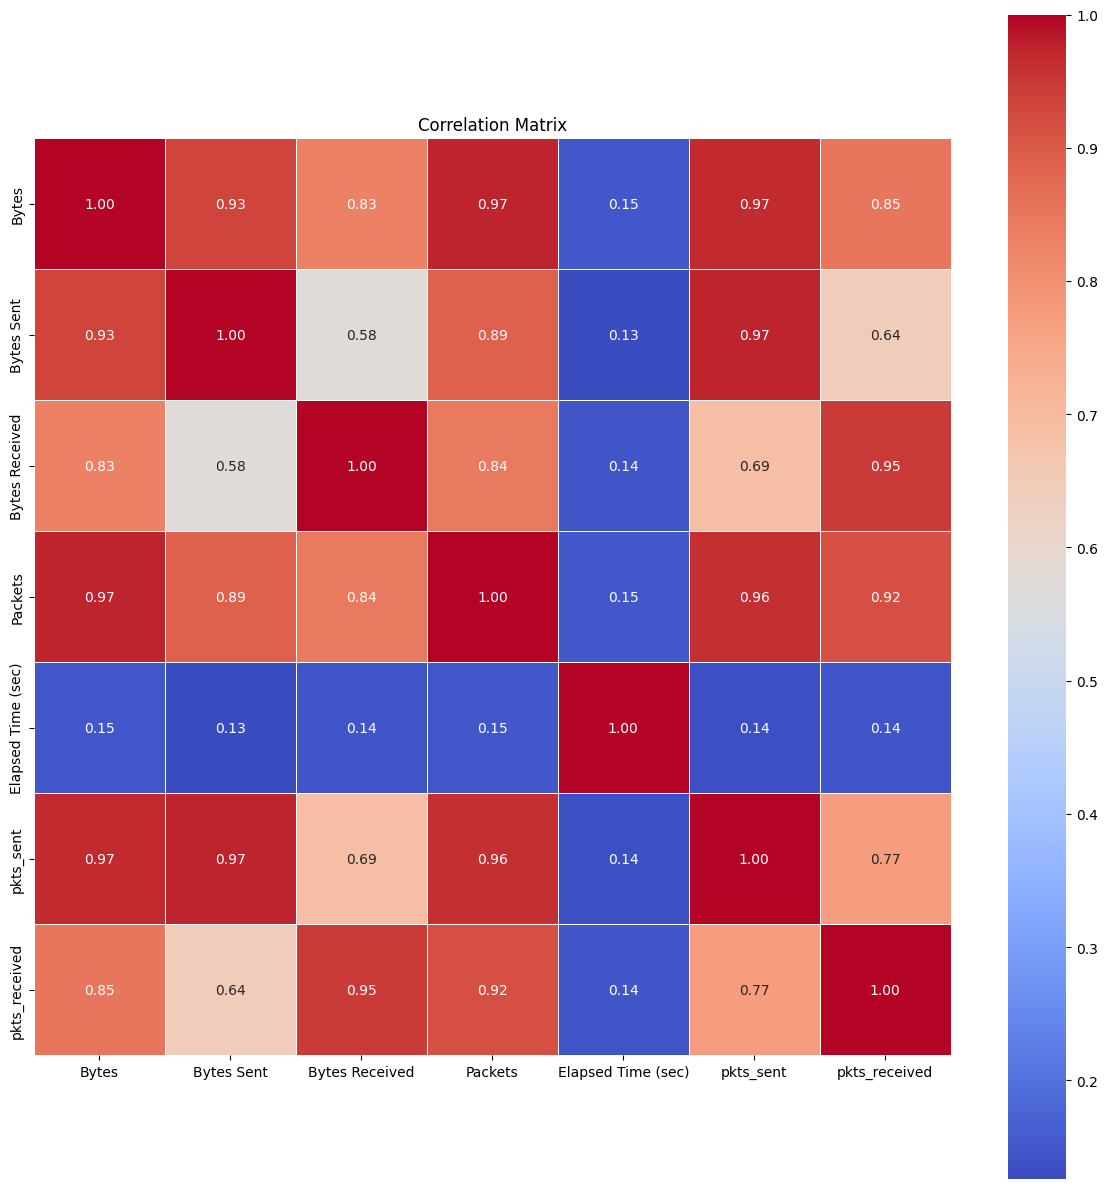

In [12]:
corr = df_num.corr(method='pearson')
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

- The Cross correlation matrix exhibit potential high collinearity between Bytes groups and Packets groups, except for Elapsed Time
- Next we compute VIF score to check if there is any significant collinearity

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = df_num.columns
vif_data['VIF'] = [variance_inflation_factor(df_num.values, i) for i in range(df_num.shape[1])]
vif_data = vif_data.sort_values(by="VIF",ascending=False)
print(vif_data)

              Feature       VIF
0               Bytes       inf
1          Bytes Sent       inf
2      Bytes Received       inf
3             Packets       inf
5           pkts_sent       inf
6       pkts_received       inf
4  Elapsed Time (sec)  1.024883


/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


- VIF suggests severe multicollinearity between Bytes and Packets groups.
- The reason is that Bytes = Bytes Sent+Bytes Received; Packets = Packets Sent+Packets Received
- It suggests to use the representation features for futher analytics
- The following analytics return VIF of 19 for the 2 remaining Bytes and Packets features, implying these could be useful for the modeling

In [14]:
df_num_sel = df_num[["Bytes", "Packets", "Elapsed Time (sec)"]]
vif_data = pd.DataFrame()
vif_data['Feature'] = df_num_sel.columns
vif_data['VIF'] = [variance_inflation_factor(df_num_sel.values, i) for i in range(df_num_sel.shape[1])]
vif_data = vif_data.sort_values(by="VIF",ascending=False)
print(vif_data)

              Feature        VIF
0               Bytes  19.782472
1             Packets  19.775615
2  Elapsed Time (sec)   1.022879


#### One Hot Encoding categorical features and Scale numerical features
- For the 4 categorical data, Source Port and NAT Source Port have more than 30% unique, with the unique values more than 22000 and 29000 respectively. If we apply the regular OHE approach to this categorical data, it will result in tens of thousands of new features that make the input dataset sparse and wide hence increasing the memory usage, also, the ML model is really inefficient
- For this kind of dataset, we would apply the technique called Top-N encoding, where N is fixed amount of number to be retained. For example, out of 22000 unique values, we retain the top 100 most frequency features and mark all the rest as "Others". This technique requires careful evaluation of N.
- After carefully consideration, we propose N to be the top 1% of each categorical data, hence N number varies for different categorical features.
- Following is the code to retain top-N features for 4 categorical data and apply OHE to each of the 4 features.

In [15]:
def top_n_encode_column(df, column_name, other_label="Other", top_n_ratio=0.010):
    df_copy = df.copy()
    # Calculate frequency
    freq = df_copy[column_name].value_counts()    
    # Determine number of top-N values to keep
    num_unique = freq.shape[0]
    n_top = max(1, int(num_unique * top_n_ratio))
    # Get top-N frequent values
    top_n_values = freq.head(n_top).index.tolist()
    # Apply encoding
    df_copy[column_name + "_topN"] = df_copy[column_name].apply(
        lambda x: x if x in top_n_values else other_label
    )
    return df_copy


In [16]:
df_cat = df[['Source Port', 'Destination Port', 'NAT Source Port', 'NAT Destination Port']]

In [17]:
df_cat = top_n_encode_column(df_cat,"Source Port")
df_cat = top_n_encode_column(df_cat,"Destination Port")
df_cat = top_n_encode_column(df_cat,"NAT Source Port")
df_cat = top_n_encode_column(df_cat,"NAT Destination Port")

In [18]:
df_cat = df_cat.iloc[:,4:]

In [19]:
df_cat.head()

,Source Port_topN,Destination Port_topN,NAT Source Port_topN,NAT Destination Port_topN
0,Other,53,Other,53
1,Other,3389,Other,3389
2,6881,Other,Other,Other
3,Other,3389,Other,3389
4,Other,443,Other,443


In [20]:
df_cat_ohe = pd.get_dummies(df_cat, drop_first=False,dtype=int)

In [21]:
df_cat_ohe.head()

,Source Port_topN_0,Source Port_topN_80,Source Port_topN_123,Source Port_topN_443,Source Port_topN_993,Source Port_topN_1024,Source Port_topN_1025,Source Port_topN_1027,Source Port_topN_2267,Source Port_topN_3478,...,NAT Destination Port_topN_8080,NAT Destination Port_topN_8999,NAT Destination Port_topN_15000,NAT Destination Port_topN_27015,NAT Destination Port_topN_27016,NAT Destination Port_topN_27017,NAT Destination Port_topN_27018,NAT Destination Port_topN_40010,NAT Destination Port_topN_51413,NAT Destination Port_topN_Other
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df_num_std = pd.DataFrame(StandardScaler().fit_transform(df_num_sel))
df_num_std.columns = df_num_sel.columns

In [23]:
X = pd.concat([df_cat_ohe, df_num_std], axis=1)

In [24]:
y = df.Action

## Modeling with SVM
Now we will use SVM in scikit learn for modeling

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=123)

In [27]:
SVM_model = SVC(C=1,kernel="linear",probability=True)

In [28]:
SVM_model.fit(X_train,y_train)

SVC(C=1, kernel='linear', probability=True)

In [29]:
y_pred_svm = SVM_model.predict(X_test)

In [30]:
accuracy_score(y_pred_svm,y_test)

0.9966430151827268

In [ ]:
%%time
for i in [1E-3,1E-2,1E-1,1,10,100,1000]:
    SVM_model.C = i
    print(i,cross_val_score(SVM_model,X,y,cv=5,scoring="accuracy",n_jobs=-1))

0.001 [0.99328603 0.99130236 0.9916069  0.98580803 0.98687624]

0.01 [0.99664302 0.99618524 0.99572715 0.99282771 0.99412483] 

0.1 [0.99664302 0.99618524 0.99572715 0.99282771 0.99412483] 

1 [0.99725338 0.99656672 0.99633756 0.99404853 0.99618495]


- Because the linear model is able to deliver very high accuracy, we will stop with this linear kernel and not going forward with nonlinear model (with kernel of poly or RBF)
- Is N = top 1% a good choice? We are not sure, but it seems it is acceptable for now
- SVM is powerful tool for small and medium size, in this case we have about 500 features with 65000 rows, which considered to be a large dataset. It consumes lots of computational time for this.
- Overfitting might be an issues here as well


## Modeling with SGD 
- With this large dataset, we should use SGD, 

In [33]:
from sklearn.linear_model import SGDClassifier
SGD_model = SGDClassifier(loss='log_loss',        
                  max_iter=1000,       
                  early_stopping=True, 
                  validation_fraction=0.1,  
                  n_iter_no_change=5,  
                  tol=1e-3,     
                  learning_rate="constant",
                  eta=0.01,      
                  random_state=123)

In [34]:
SGD_model.fit(X_train,y_train)

SGDClassifier(early_stopping=True, loss='log_loss', random_state=123)

In [35]:
y_pred_SGD = SGD_model.predict(X_test)

In [36]:
accuracy_score(y_pred_SGD,y_test)

0.995727473868925

In [37]:
%%time
scores = cross_val_score(SGD_model, X_train, y_train, cv=5, scoring='accuracy',n_jobs=-1)
print("CV scores:", scores)
print("Mean CV score:", scores.mean())

CV scores: [0.99465904 0.99465904 0.99513591 0.99504053 0.99523128]
Mean CV score: 0.9949451597520266
CPU times: user 113 ms, sys: 348 ms, total: 461 ms
Wall time: 3.09 s


### Comparative ROC between SVM and SGD


In [61]:
y_SVM = SVM_model.predict_proba(X_test)
y_SGD = SGD_model.predict_proba(X_test)

In [ ]:
y_test[:, i]

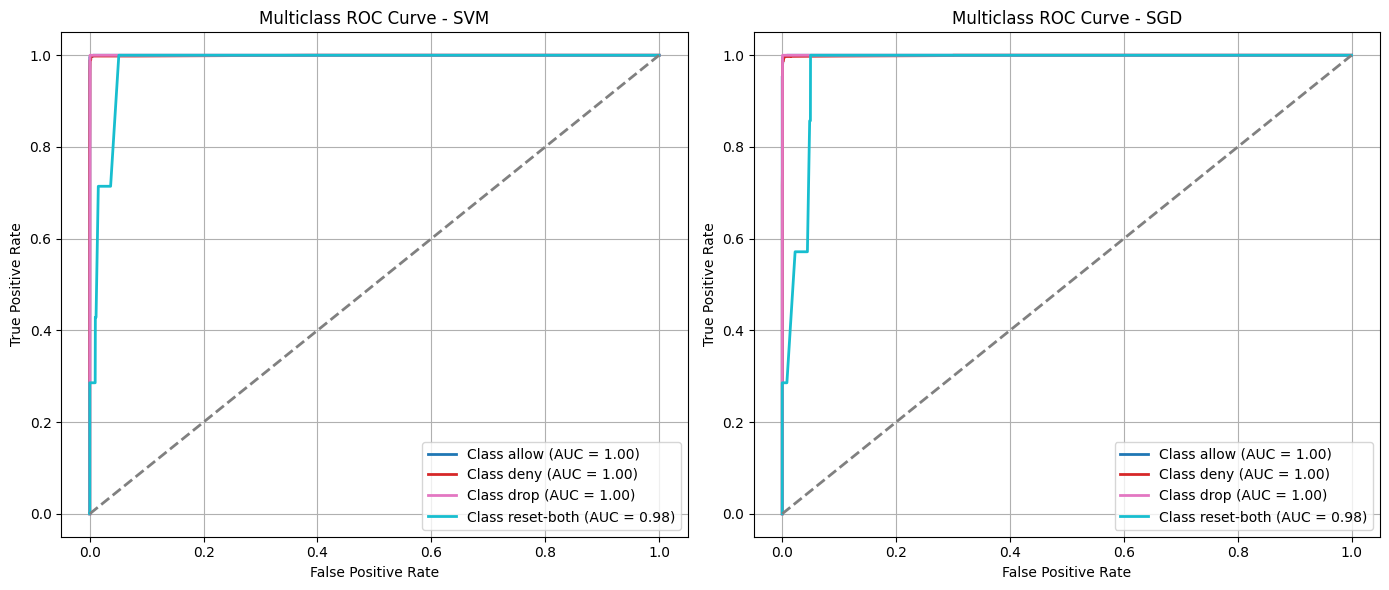

In [66]:
classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Plot for y_SVM ----
ax = axes[0]
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_SVM[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'Class {class_label} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax.set_title("Multiclass ROC Curve - SVM")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right')
ax.grid(True)

# ---- Plot for y_SGD ----
ax = axes[1]
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_SGD[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'Class {class_label} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
ax.set_title("Multiclass ROC Curve - SGD")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right')
ax.grid(True)

plt.tight_layout()
plt.show()


In [68]:
report_svm = classification_report(y_test,y_pred_svm,output_dict=True)
report_sgd  = classification_report(y_test,y_pred_SGD,output_dict=True)


/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/users/tuev/tensorf

In [69]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7557
        deny       1.00      0.99      0.99      2942
        drop       1.00      1.00      1.00      2601
  reset-both       0.00      0.00      0.00         7

    accuracy                           1.00     13107
   macro avg       0.75      0.75      0.75     13107
weighted avg       1.00      1.00      1.00     13107



/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [71]:
print(classification_report(y_test,y_pred_SGD))

              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7557
        deny       0.99      1.00      0.99      2942
        drop       1.00      1.00      1.00      2601
  reset-both       0.00      0.00      0.00         7

    accuracy                           1.00     13107
   macro avg       0.75      0.75      0.75     13107
weighted avg       1.00      1.00      1.00     13107



/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/users/tuev/tensorflow_2.9/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
